# Ejercicio 2 - Medición de riesgo de crédito con simulación Monte Carlo

En este ejercicio se estima la distribución de pérdidas para dos carteras: **gubernamental** y **auto**.

In [15]:
import pandas as pd
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter
from IPython.display import display, Markdown

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:,.4f}".format

## Parámetros del análisis

- `rho` representa la correlación de activos asumida entre acreditados. 
- `n_sim` controla el número de escenarios Monte Carlo. 
- La pérdida por crédito se define como `EAD * LGD` cuando ocurre incumplimiento.

In [16]:
archivo_excel = r"Tarea 2.xlsx"
hoja = "Ejercicio 2 (Datos)"

rho = 0.20
n_sim = 20_000
seed = 42
percentiles = [95, 99, 99.9]

raw = pd.read_excel(archivo_excel, sheet_name=hoja, header=None)
print(f"Base cargada: {raw.shape[0]:,} filas x {raw.shape[1]:,} columnas")

Base cargada: 9,802 filas x 16 columnas


## ¿Cómo se hace la simulación?

La cartera se modela crédito por crédito. Para cada acreditado $i$, se usan tres variables principales:

- $EAD_i$: exposición al momento del incumplimiento.
- $LGD_i$: severidad de la pérdida, es decir, proporción no recuperada.
- $PD_i$: probabilidad de incumplimiento.

Si el crédito $i$ incumple, su pérdida es:

$$
L_i = EAD_i \times LGD_i
$$

La pérdida total de la cartera en un escenario simulado es:

$$
L = \sum_{i=1}^{N} I_i \cdot EAD_i \cdot LGD_i
$$

Donde $I_i$ es una variable indicadora:

$$
I_i =
\begin{cases}
1, & \text{si el crédito incumple} \\
0, & \text{si el crédito no incumple}
\end{cases}
$$

### Modelo de un factor gaussiano

Para incorporar dependencia entre incumplimientos se usa un factor sistemático común $M$, que representa el estado general de la economía o del mercado. El valor latente del acreditado se escribe como:

$$
X_i = \sqrt{\rho}M + \sqrt{1-\rho}\epsilon_i
$$

Donde:

- $M \sim N(0,1)$ es el factor común.
- $\epsilon_i \sim N(0,1)$ es el riesgo idiosincrático del crédito.
- $\rho$ es la correlación de activos.

El crédito incumple si su variable latente cae por debajo de un umbral asociado a su probabilidad de incumplimiento:

$$
X_i < \Phi^{-1}(PD_i)
$$

Condicionado al factor común $M$, la probabilidad de incumplimiento se calcula como:

$$
PD_i(M) = \Phi\left(\frac{\Phi^{-1}(PD_i)-\sqrt{\rho}M}{\sqrt{1-\rho}}\right)
$$

Esta es la fórmula que aparece en el código como `conditional_pd`. Después, para cada simulación, se genera un número uniforme $U_i \sim U(0,1)$. El crédito incumple cuando:

$$
U_i < PD_i(M)
$$

### Medidas de riesgo

La pérdida esperada es el promedio de las pérdidas simuladas:

$$
EL = \mathbb{E}[L]
$$

También puede aproximarse de forma analítica como:

$$
EL \approx \sum_{i=1}^{N} PD_i \cdot EAD_i \cdot LGD_i
$$

El VaR al nivel $\alpha$ es el percentil $\alpha$ de la distribución de pérdidas:

$$
VaR_\alpha = \inf\{l: P(L \leq l) \geq \alpha\}
$$

Por ejemplo, $VaR_{99\%}$ indica una pérdida que solo se supera en aproximadamente 1 de cada 100 escenarios simulados.

El Expected Shortfall mide la pérdida promedio en los escenarios que exceden el VaR:

$$
ES_\alpha = \mathbb{E}[L \mid L \geq VaR_\alpha]
$$

Finalmente, el capital económico se calcula como la pérdida extrema menos la pérdida esperada:

$$
Capital\ Económico_\alpha = VaR_\alpha - EL
$$

La pérdida esperada mide el costo promedio del riesgo, mientras que VaR, ES y capital económico describen qué tan severa puede ser la cola de pérdidas bajo escenarios adversos.

## Funciones auxiliares


In [17]:
def money(x, decimals=0):
    return f"${x:,.{decimals}f}"


def pct(x, decimals=2):
    return f"{100 * x:.{decimals}f}%"


def prepare_gubernamental(raw):
    gub_raw = raw.iloc[2:4638, 0:7].copy()
    gub_raw.columns = [
        "CVE_PERI", "CVE_INSTI", "DAT_ID_CRED", "DAT_RESPONSA",
        "DAT_SP_TI", "DAT_EPRC", "DAT_PI_TOTAL"
    ]

    gub = pd.DataFrame({
        "EAD": pd.to_numeric(gub_raw["DAT_RESPONSA"], errors="coerce"),
        "LGD": pd.to_numeric(gub_raw["DAT_SP_TI"], errors="coerce") / 100,
        "PD": pd.to_numeric(gub_raw["DAT_PI_TOTAL"], errors="coerce") / 100,
    })

    gub = gub.dropna()
    gub = gub[(gub["EAD"] > 0) & (gub["LGD"] > 0) & (gub["PD"] > 0)].copy()
    gub["EAD_LGD"] = gub["EAD"] * gub["LGD"]
    gub["EL_individual"] = gub["EAD_LGD"] * gub["PD"]
    return gub


def prepare_auto(raw):
    auto_raw = raw.iloc[2:4638, 9:16].copy()
    auto_raw.columns = ["Fecha", "Inst", "FolioCred", "SdoCred", "SeveriNC", "Rvas", "Probab"]

    auto = pd.DataFrame({
        "EAD": pd.to_numeric(auto_raw["SdoCred"], errors="coerce"),
        "LGD": pd.to_numeric(auto_raw["SeveriNC"], errors="coerce"),
        "PD": pd.to_numeric(auto_raw["Probab"], errors="coerce") / 100,
        "Rvas": pd.to_numeric(auto_raw["Rvas"], errors="coerce"),
    }).astype({
        "EAD": "float64",
        "LGD": "float64",
        "PD": "float64",
        "Rvas": "float64",
    })

    denominador = auto["EAD"] * auto["PD"]
    lgd_calculada = np.divide(
        auto["Rvas"],
        denominador,
        out=np.full(len(auto), np.nan, dtype="float64"),
        where=denominador.to_numpy() != 0,
    )

    mask = auto["LGD"].isna() | (auto["LGD"] == 0)
    auto["LGD"] = np.where(mask, lgd_calculada, auto["LGD"].to_numpy(dtype="float64"))

    auto = auto.replace([np.inf, -np.inf], np.nan).dropna()
    auto = auto[(auto["EAD"] > 0) & (auto["LGD"] > 0) & (auto["LGD"] <= 1) & (auto["PD"] > 0)].copy()
    auto["EAD_LGD"] = auto["EAD"] * auto["LGD"]
    auto["EL_individual"] = auto["EAD_LGD"] * auto["PD"]
    return auto.drop(columns=["Rvas"])


def portfolio_profile(df, name):
    weights_ead = df["EAD"] / df["EAD"].sum()
    weights_el = df["EL_individual"] / df["EL_individual"].sum()
    top_10_ead_share = df.nlargest(10, "EAD")["EAD"].sum() / df["EAD"].sum()
    hhi = np.square(weights_ead).sum()

    profile = pd.DataFrame({
        "Metrica": [
            "Numero de creditos", "EAD total", "EAD promedio", "EAD mediana",
            "PD promedio simple", "PD ponderada por EAD", "LGD promedio simple",
            "LGD ponderada por EAD", "Perdida esperada analitica", "EL / EAD",
            "Participacion top 10 por EAD", "HHI de concentracion"
        ],
        name: [
            len(df), df["EAD"].sum(), df["EAD"].mean(), df["EAD"].median(),
            df["PD"].mean(), np.average(df["PD"], weights=df["EAD"]), df["LGD"].mean(),
            np.average(df["LGD"], weights=df["EAD"]), df["EL_individual"].sum(),
            df["EL_individual"].sum() / df["EAD"].sum(), top_10_ead_share, hhi
        ]
    })
    return profile


def simulate_one_factor_losses(df, rho=0.20, n_sim=20_000, seed=42):
    rng = np.random.default_rng(seed)
    market_factor = rng.normal(0, 1, n_sim)
    losses = np.zeros(n_sim)
    sqrt_rho = np.sqrt(rho)
    sqrt_1_rho = np.sqrt(1 - rho)

    for pd_val, group in df.groupby("PD", sort=False):
        threshold = norm.ppf(pd_val)
        conditional_pd = norm.cdf((threshold - sqrt_rho * market_factor) / sqrt_1_rho)
        conditional_pd = np.clip(conditional_pd, 0, 1)
        exposure_at_loss = group["EAD_LGD"].to_numpy()
        uniforms = rng.uniform(size=(n_sim, len(exposure_at_loss)))
        losses += (uniforms < conditional_pd[:, None]) @ exposure_at_loss

    return losses


def loss_metrics(losses, df, name):
    metrics = {
        "EL simulada": losses.mean(),
        "EL analitica": df["EL_individual"].sum(),
        "Desviacion estandar": losses.std(ddof=1),
    }

    for q in percentiles:
        var = np.percentile(losses, q)
        es = losses[losses >= var].mean()
        metrics[f"VaR {q}%"] = var
        metrics[f"ES {q}%"] = es
        metrics[f"Capital economico {q}%"] = var - losses.mean()

    return pd.DataFrame({"Metrica": metrics.keys(), name: metrics.values()})


def plot_portfolio_profile(df, title):
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle(f"Perfil de la cartera: {title}", fontsize=15, fontweight="bold")

    axes[0, 0].hist(df["EAD"], bins=50, color="#2F6F8F", edgecolor="white")
    axes[0, 0].set_title("Distribucion de exposiciones")
    axes[0, 0].set_xlabel("EAD")
    axes[0, 0].xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"${x/1e6:,.1f}M"))

    axes[0, 1].hist(df["PD"], bins=50, color="#7A9E3A", edgecolor="white")
    axes[0, 1].set_title("Distribucion de PD")
    axes[0, 1].set_xlabel("PD")
    axes[0, 1].xaxis.set_major_formatter(PercentFormatter(1))

    axes[1, 0].hist(df["LGD"], bins=50, color="#B35C44", edgecolor="white")
    axes[1, 0].set_title("Distribucion de LGD")
    axes[1, 0].set_xlabel("LGD")
    axes[1, 0].xaxis.set_major_formatter(PercentFormatter(1))

    size = 20 + 180 * (df["LGD"] / df["LGD"].max())
    axes[1, 1].scatter(df["PD"], df["EAD"], s=size, alpha=0.45, color="#4C5F7A", edgecolors="none")
    axes[1, 1].set_title("PD vs EAD; tamano segun LGD")
    axes[1, 1].set_xlabel("PD")
    axes[1, 1].set_ylabel("EAD")
    axes[1, 1].xaxis.set_major_formatter(PercentFormatter(1))
    axes[1, 1].yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"${x/1e6:,.1f}M"))

    plt.tight_layout()
    plt.show()


def plot_loss_distribution(losses, metrics_df, name):
    metrics = dict(zip(metrics_df["Metrica"], metrics_df[name]))
    fig, ax = plt.subplots(figsize=(12, 5.5))

    ax.hist(losses, bins=75, density=True, alpha=0.78, color="#557A95", edgecolor="white")
    ax.axvline(metrics["EL simulada"], color="#1B4332", linewidth=2.5, label="EL simulada")
    ax.axvline(metrics["VaR 95%"], color="#B08900", linestyle="--", linewidth=2, label="VaR 95%")
    ax.axvline(metrics["VaR 99%"], color="#9D4EDD", linestyle="--", linewidth=2, label="VaR 99%")
    ax.axvline(metrics["VaR 99.9%"], color="#C1121F", linestyle="--", linewidth=2, label="VaR 99.9%")

    ax.set_title(f"Distribucion simulada de perdidas - {name}", fontsize=14, fontweight="bold")
    ax.set_xlabel("Perdida")
    ax.set_ylabel("Densidad")
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"${x/1e6:,.1f}M"))
    ax.legend(frameon=True)
    plt.tight_layout()
    plt.show()


def plot_tail(losses, name):
    sorted_losses = np.sort(losses)
    cum_prob = np.arange(1, len(sorted_losses) + 1) / len(sorted_losses)

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(sorted_losses, cum_prob, color="#264653", linewidth=2)
    for q, color in zip(percentiles, ["#B08900", "#9D4EDD", "#C1121F"]):
        ax.axvline(np.percentile(losses, q), color=color, linestyle="--", label=f"VaR {q}%")
    ax.set_title(f"Funcion de distribucion acumulada - {name}", fontsize=14, fontweight="bold")
    ax.set_xlabel("Perdida")
    ax.set_ylabel("Probabilidad acumulada")
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"${x/1e6:,.1f}M"))
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.legend(frameon=True)
    plt.tight_layout()
    plt.show()


def interpret_portfolio(df, metrics_df, name):
    metrics = dict(zip(metrics_df["Metrica"], metrics_df[name]))
    ead_total = df["EAD"].sum()
    el_ratio = metrics["EL simulada"] / ead_total
    var99_ratio = metrics["VaR 99%"] / ead_total
    capital99_ratio = metrics["Capital economico 99%"] / ead_total
    top10 = df.nlargest(10, "EAD")["EAD"].sum() / ead_total

    text = f"""
La cartera tiene **{len(df):,} creditos** y una exposicion total de **{money(ead_total)}**. La perdida esperada simulada es **{money(metrics['EL simulada'])}**, equivalente a **{pct(el_ratio)}** de la exposicion total.

El **VaR al 99%** es **{money(metrics['VaR 99%'])}**, por lo que el capital economico sobre la perdida esperada seria aproximadamente **{money(metrics['Capital economico 99%'])}** (**{pct(capital99_ratio)}** de la exposicion total). El **Expected Shortfall al 99%** asciende a **{money(metrics['ES 99%'])}**, que resume la perdida promedio una vez que se rebasa el VaR 99%.

La participacion de los 10 creditos mas grandes es **{pct(top10)}**. Si esta proporcion es elevada, los percentiles extremos pueden estar influidos por pocos acreditados grandes; si es baja, el riesgo esta mas diversificado. En esta simulacion, el supuesto de correlacion `rho = {rho:.2f}` hace que los incumplimientos se agrupen en escenarios macro adversos, elevando la cola derecha de la distribucion.
"""
    display(Markdown(text))

## Cartera 1: Gubernamental

Primero se limpia la información gubernamental, convirtiendo exposición, severidad y probabilidad de incumplimiento a variables numéricas comparables. Después se revisa el perfil de la cartera antes de simular pérdidas.

Numero de creditos validos: 4,378


,Metrica,Gubernamental
0,Numero de creditos,"4,378.0000"
1,EAD total,"789,852,920,716.0000"
2,EAD promedio,"180,414,097.9251"
3,EAD mediana,"13,483,797.0000"
4,PD promedio simple,0.0345
5,PD ponderada por EAD,0.0338
6,LGD promedio simple,0.4001
7,LGD ponderada por EAD,0.2721
8,Perdida esperada analitica,"5,262,902,144.4501"
9,EL / EAD,0.0067


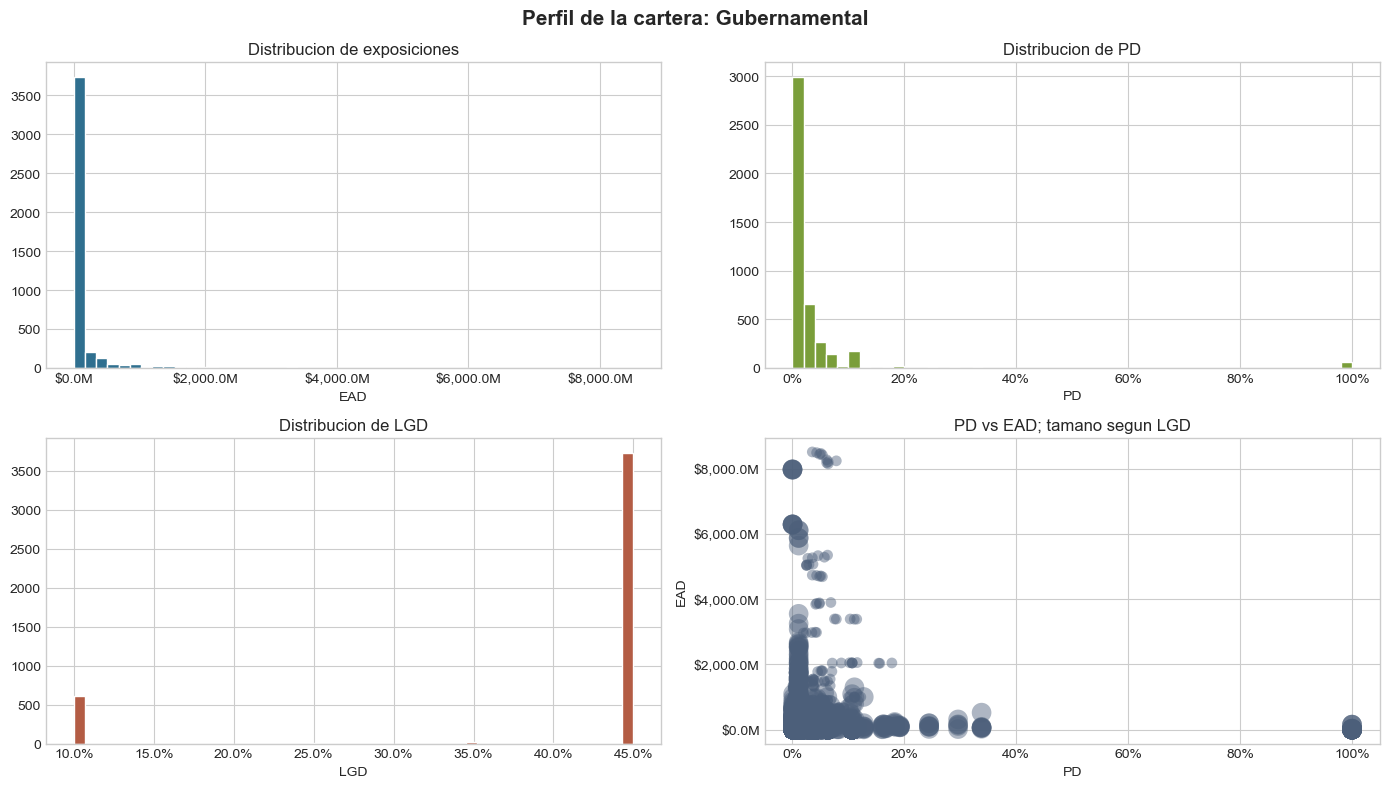

In [18]:
gub = prepare_gubernamental(raw)
perfil_gub = portfolio_profile(gub, "Gubernamental")

print(f"Numero de creditos validos: {len(gub):,}")
display(perfil_gub)
plot_portfolio_profile(gub, "Gubernamental")

,Metrica,Gubernamental
0,EL simulada,"5,250,782,388.6596"
1,EL analitica,"5,262,902,144.4501"
2,Desviacion estandar,"5,316,792,805.3070"
3,VaR 95%,"15,554,363,137.9450"
4,ES 95%,"22,001,531,233.4083"
5,Capital economico 95%,"10,303,580,749.2854"
6,VaR 99%,"25,812,867,592.8875"
7,ES 99%,"32,839,553,421.9050"
8,Capital economico 99%,"20,562,085,204.2278"
9,VaR 99.9%,"42,211,460,116.0391"


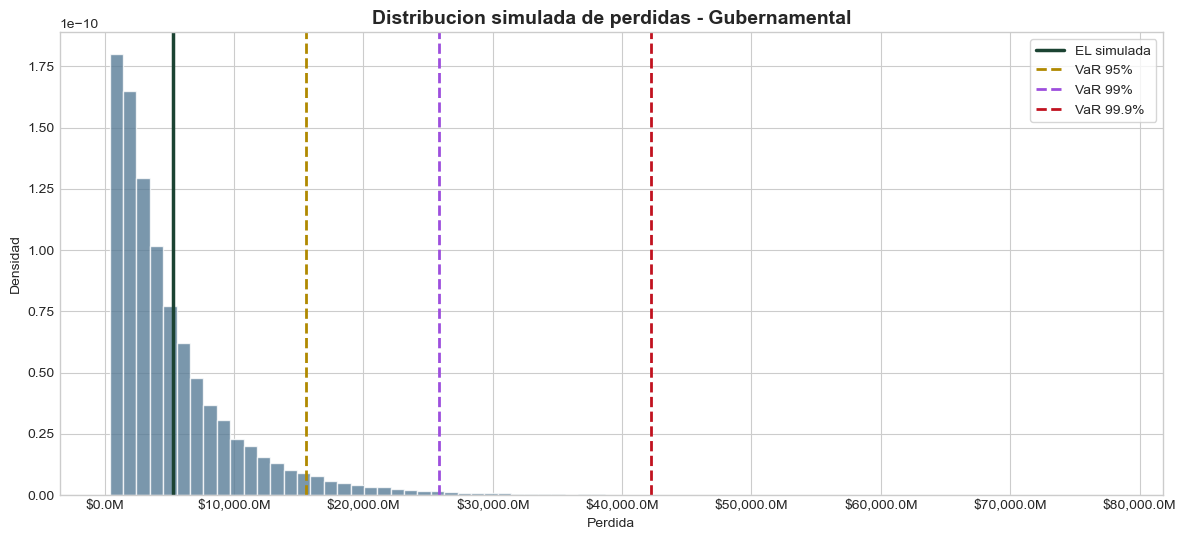

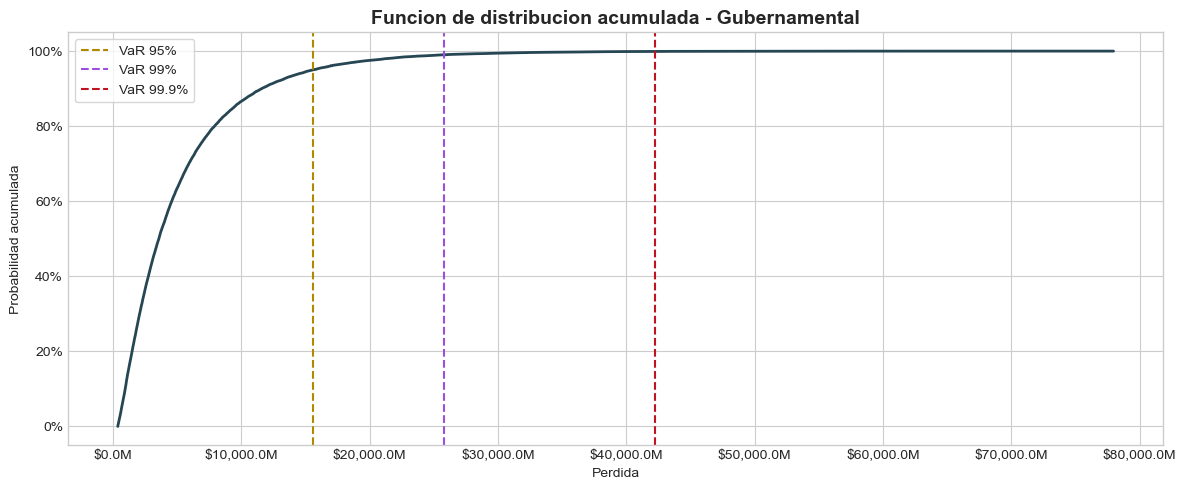


La cartera tiene **4,378 creditos** y una exposicion total de **$789,852,920,716**. La perdida esperada simulada es **$5,250,782,389**, equivalente a **0.66%** de la exposicion total.

El **VaR al 99%** es **$25,812,867,593**, por lo que el capital economico sobre la perdida esperada seria aproximadamente **$20,562,085,204** (**2.60%** de la exposicion total). El **Expected Shortfall al 99%** asciende a **$32,839,553,422**, que resume la perdida promedio una vez que se rebasa el VaR 99%.

La participacion de los 10 creditos mas grandes es **10.55%**. Si esta proporcion es elevada, los percentiles extremos pueden estar influidos por pocos acreditados grandes; si es baja, el riesgo esta mas diversificado. En esta simulacion, el supuesto de correlacion `rho = 0.20` hace que los incumplimientos se agrupen en escenarios macro adversos, elevando la cola derecha de la distribucion.


In [19]:
losses_gub = simulate_one_factor_losses(gub, rho=rho, n_sim=n_sim, seed=seed)
metricas_gub = loss_metrics(losses_gub, gub, "Gubernamental")

display(metricas_gub)
plot_loss_distribution(losses_gub, metricas_gub, "Gubernamental")
plot_tail(losses_gub, "Gubernamental")
interpret_portfolio(gub, metricas_gub, "Gubernamental")

## Cartera 2: Auto


Numero de creditos validos: 4,636


,Metrica,Auto
0,Numero de creditos,"4,636.0000"
1,EAD total,"787,067,076.9000"
2,EAD promedio,"169,772.8811"
3,EAD mediana,"165,816.5750"
4,PD promedio simple,0.0133
5,PD ponderada por EAD,0.0139
6,LGD promedio simple,0.7205
7,LGD ponderada por EAD,0.7204
8,Perdida esperada analitica,"7,926,621.3600"
9,EL / EAD,0.0101


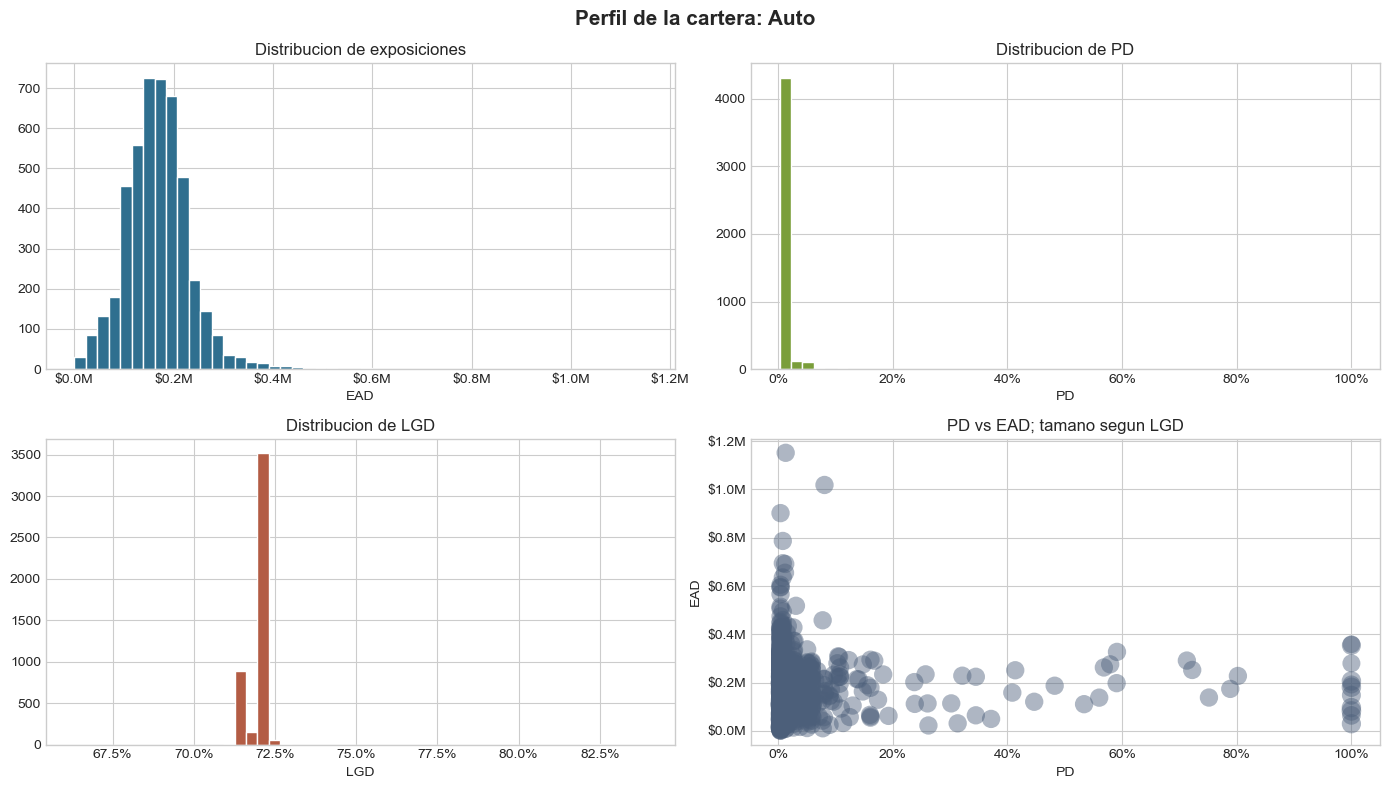

In [20]:
auto = prepare_auto(raw)
perfil_auto = portfolio_profile(auto, "Auto")

print(f"Numero de creditos validos: {len(auto):,}")
display(perfil_auto)
plot_portfolio_profile(auto, "Auto")

,Metrica,Auto
0,EL simulada,"7,968,476.0601"
1,EL analitica,"7,926,621.3600"
2,Desviacion estandar,"7,146,307.2104"
3,VaR 95%,"21,213,195.9855"
4,ES 95%,"31,490,600.6766"
5,Capital economico 95%,"13,244,719.9255"
6,VaR 99%,"37,508,664.5177"
7,ES 99%,"49,047,474.4628"
8,Capital economico 99%,"29,540,188.4576"
9,VaR 99.9%,"64,848,272.6072"


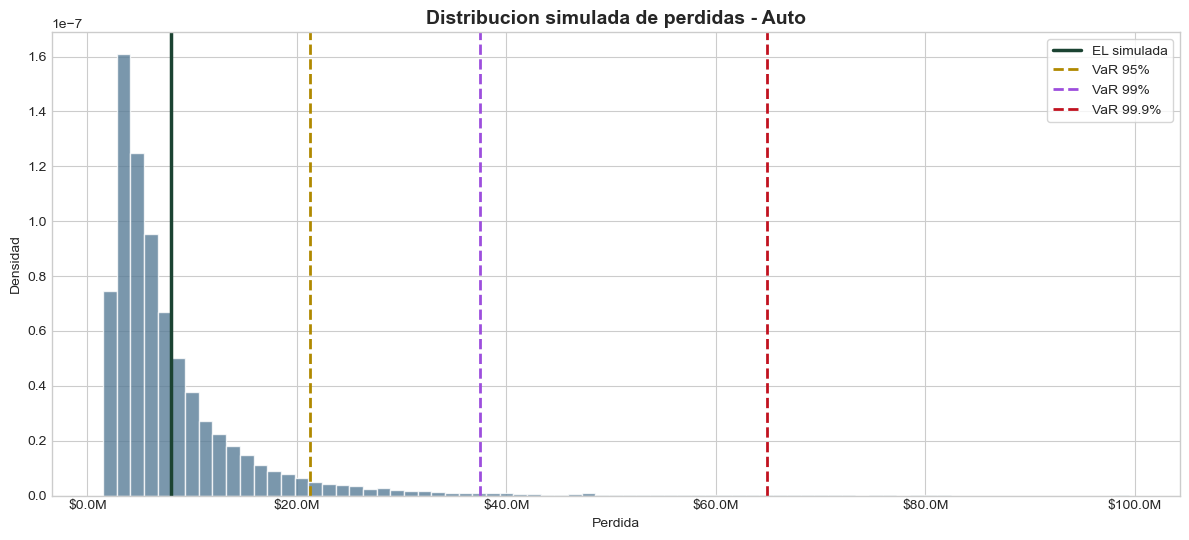

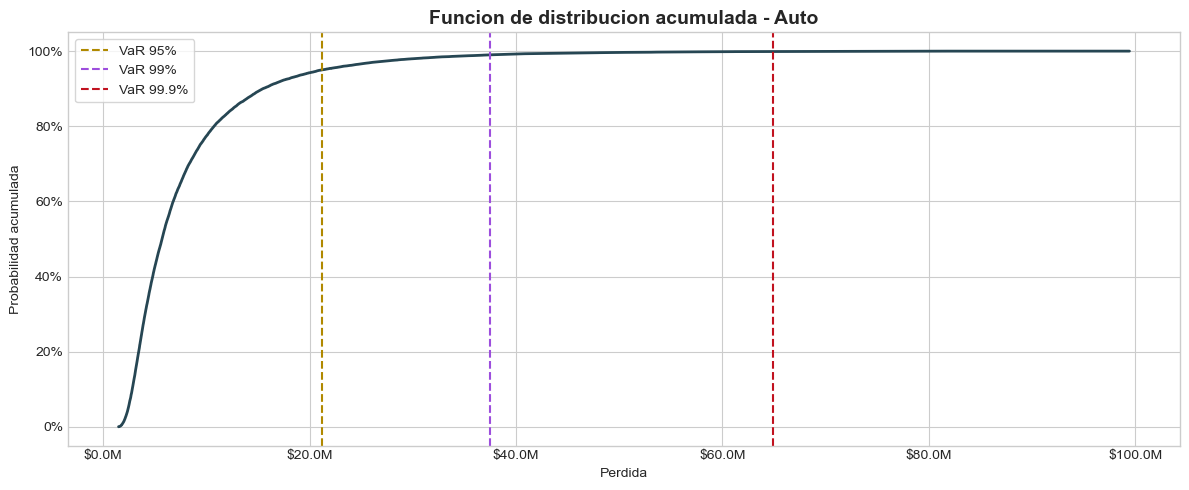


La cartera tiene **4,636 creditos** y una exposicion total de **$787,067,077**. La perdida esperada simulada es **$7,968,476**, equivalente a **1.01%** de la exposicion total.

El **VaR al 99%** es **$37,508,665**, por lo que el capital economico sobre la perdida esperada seria aproximadamente **$29,540,188** (**3.75%** de la exposicion total). El **Expected Shortfall al 99%** asciende a **$49,047,474**, que resume la perdida promedio una vez que se rebasa el VaR 99%.

La participacion de los 10 creditos mas grandes es **0.98%**. Si esta proporcion es elevada, los percentiles extremos pueden estar influidos por pocos acreditados grandes; si es baja, el riesgo esta mas diversificado. En esta simulacion, el supuesto de correlacion `rho = 0.20` hace que los incumplimientos se agrupen en escenarios macro adversos, elevando la cola derecha de la distribucion.


In [21]:
losses_auto = simulate_one_factor_losses(auto, rho=rho, n_sim=n_sim, seed=seed + 1)
metricas_auto = loss_metrics(losses_auto, auto, "Auto")

display(metricas_auto)
plot_loss_distribution(losses_auto, metricas_auto, "Auto")
plot_tail(losses_auto, "Auto")
interpret_portfolio(auto, metricas_auto, "Auto")

## Comparación de carteras


In [23]:
comparacion_perfil = perfil_gub.merge(perfil_auto, on="Metrica", how="outer")
comparacion_metricas = metricas_gub.merge(metricas_auto, on="Metrica", how="outer")

print("Descripcion de las carteras")
display(comparacion_perfil)

print("Metricas de perdida")
display(comparacion_metricas)

Descripcion de las carteras


,Metrica,Gubernamental,Auto
0,EAD mediana,"13,483,797.0000","165,816.5750"
1,EAD promedio,"180,414,097.9251","169,772.8811"
2,EAD total,"789,852,920,716.0000","787,067,076.9000"
3,EL / EAD,0.0067,0.0101
4,HHI de concentracion,0.0039,0.0003
5,LGD ponderada por EAD,0.2721,0.7204
6,LGD promedio simple,0.4001,0.7205
7,Numero de creditos,"4,378.0000","4,636.0000"
8,PD ponderada por EAD,0.0338,0.0139
9,PD promedio simple,0.0345,0.0133


Metricas de perdida


,Metrica,Gubernamental,Auto
0,Capital economico 95%,"10,303,580,749.2854","13,244,719.9255"
1,Capital economico 99%,"20,562,085,204.2278","29,540,188.4576"
2,Capital economico 99.9%,"36,960,677,727.3795","56,879,796.5471"
3,Desviacion estandar,"5,316,792,805.3070","7,146,307.2104"
4,EL analitica,"5,262,902,144.4501","7,926,621.3600"
5,EL simulada,"5,250,782,388.6596","7,968,476.0601"
6,ES 95%,"22,001,531,233.4083","31,490,600.6766"
7,ES 99%,"32,839,553,421.9050","49,047,474.4628"
8,ES 99.9%,"49,432,275,486.5082","73,108,749.6293"
9,VaR 95%,"15,554,363,137.9450","21,213,195.9855"
